# 01 - Data Exploration
Verify the dataset, inspect resolution distribution, and visualize sample images.

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from src.utils.seed import set_seed
from src.data.preprocessing import get_cat_loader
from src.utils.visualization import save_image_grid

set_seed(42)
DATA_DIR = '../data/cats'

Total images found: 9997


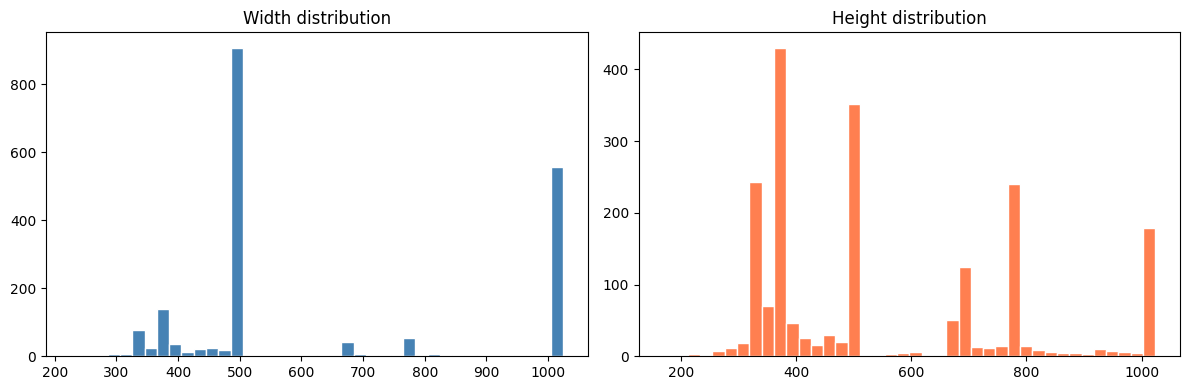

Min: 226×169  Max: 1024×1024


In [2]:
raw_paths = list(Path(DATA_DIR).rglob('*.jpg')) + list(Path(DATA_DIR).rglob('*.jpeg'))
print(f'Total images found: {len(raw_paths)}')

sizes = []
for p in raw_paths[:2000]:  # sample for speed
    with Image.open(p) as im:
        sizes.append(im.size)

widths, heights = zip(*sizes)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Width distribution')
axes[1].hist(heights, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Height distribution')
plt.tight_layout()
plt.show()
print(f'Min: {min(widths)}×{min(heights)}  Max: {max(widths)}×{max(heights)}')

In [3]:
loader = get_cat_loader(DATA_DIR, image_size=64, batch_size=64, num_workers=0)
batch = next(iter(loader))
print(f'Batch shape: {batch.shape}   min={batch.min():.2f}  max={batch.max():.2f}')
assert batch.shape == (64, 3, 64, 64), 'Unexpected shape!'
assert batch.min() >= -1.0 and batch.max() <= 1.0, 'Values out of [-1, 1]!'
print('✓ DataLoader OK')

Batch shape: torch.Size([64, 3, 64, 64])   min=-1.00  max=1.00
✓ DataLoader OK


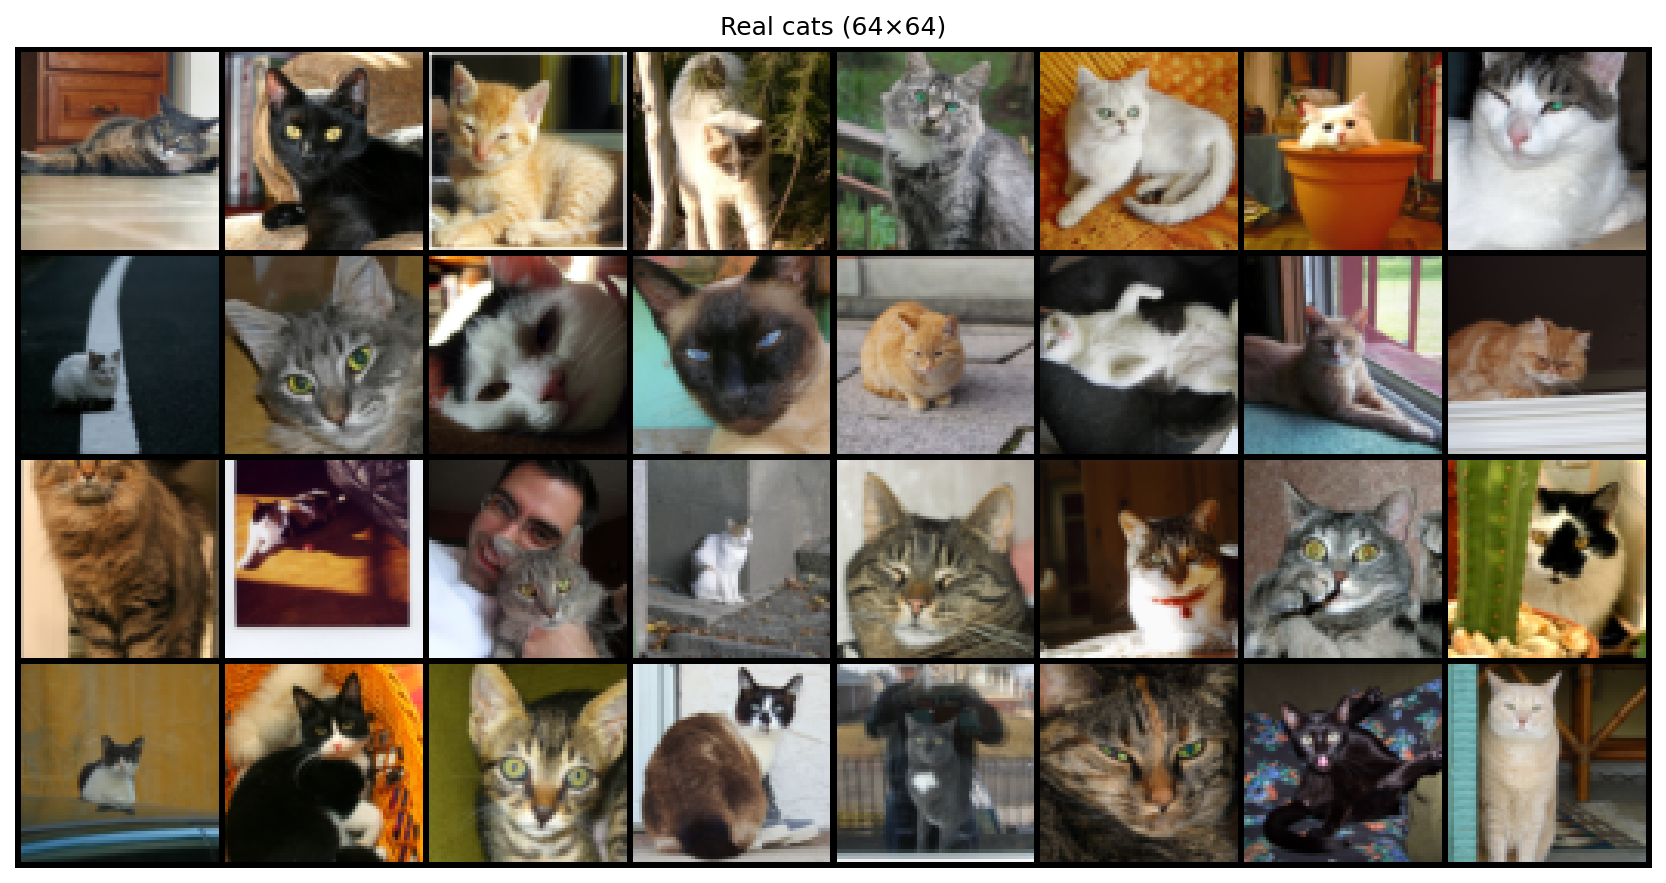

In [4]:
save_image_grid(batch[:32], '../outputs/data_samples.png', nrow=8, title='Real cats (64×64)')
from IPython.display import Image as IPImage
IPImage('../outputs/data_samples.png')